<a href="https://colab.research.google.com/github/SudeepDahal17/Openseespy/blob/main/2d_pUSHOVER_cOPY.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 86.3/86.3 MB 11.7 MB/s eta 0:00:00

PROFESSIONAL PUSHOVER ANALYSIS: 2-STORY RC FRAME
Comprehensive Visualization Suite

GEOMETRY:
  Stories: 2, Bays: 2
  Story height: 3.0 m, Bay width: 6.0 m

SECTIONS:
  Column: 400x400 mm
  Beam: 300x500 mm

CAPACITIES:
  Column My: 337.6 kN-m
  Beam My: 332.3 kN-m

NODES: 9
  Fixed base nodes: 1 to 3

MATERIALS:
  Concrete02: fc=30 MPa
  Steel02: fy=420 MPa
  Column section 1 created (Fiber)
  Beam section 2 created (Fiber)
  Elastic sections: 3 (column), 4 (beam)

CREATING ELEMENTS:
  Columns: 6
  Beams: 4
  Total hinge zones: 20

MASSES:
  Per floor: 200.0 tonnes
  Per node: 66.67 tonnes


/tmp/ipykernel_705/2926983534.py:353: UserWarning: Setting the 'color' property will override the edgecolor or facecolor properties.
  circle = Circle((x + px, y + py), 12, color='darkred', zorder=10,
/tmp/ipykernel_705/2926983534.py:361: UserWarning: Setting the 'color' property will override the edgecolor or facecolor properties.
  circle = Circle((px, y_bars), 12, color='darkred', zorder=10,



✓ Model visualization saved: opensees_output/model_visualization_professional.png


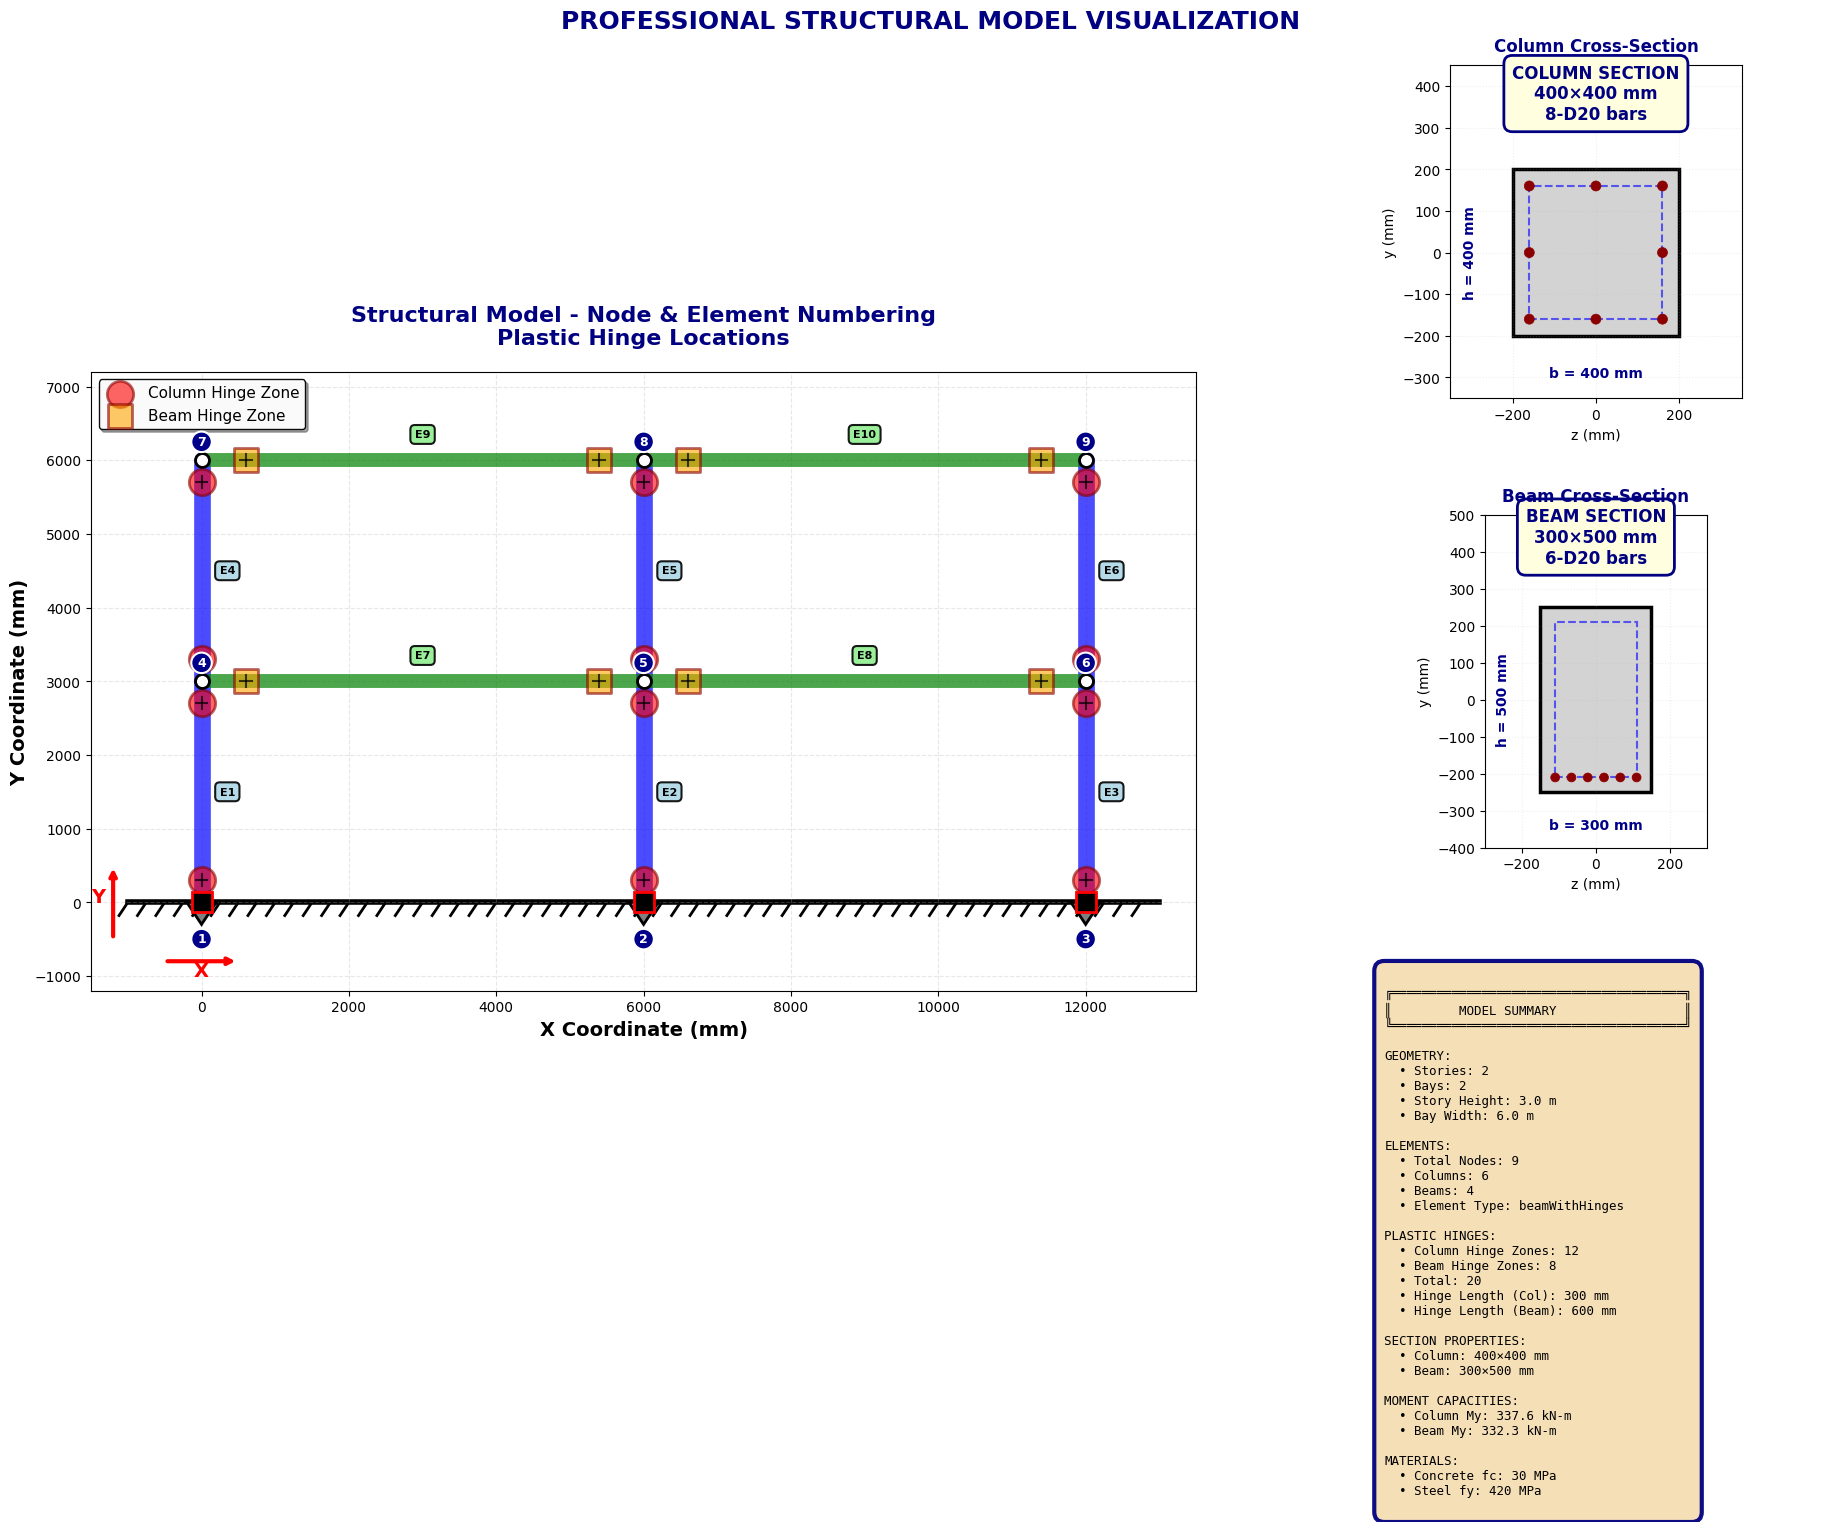

✓ Stress-strain curves saved: opensees_output/material_stress_strain.png


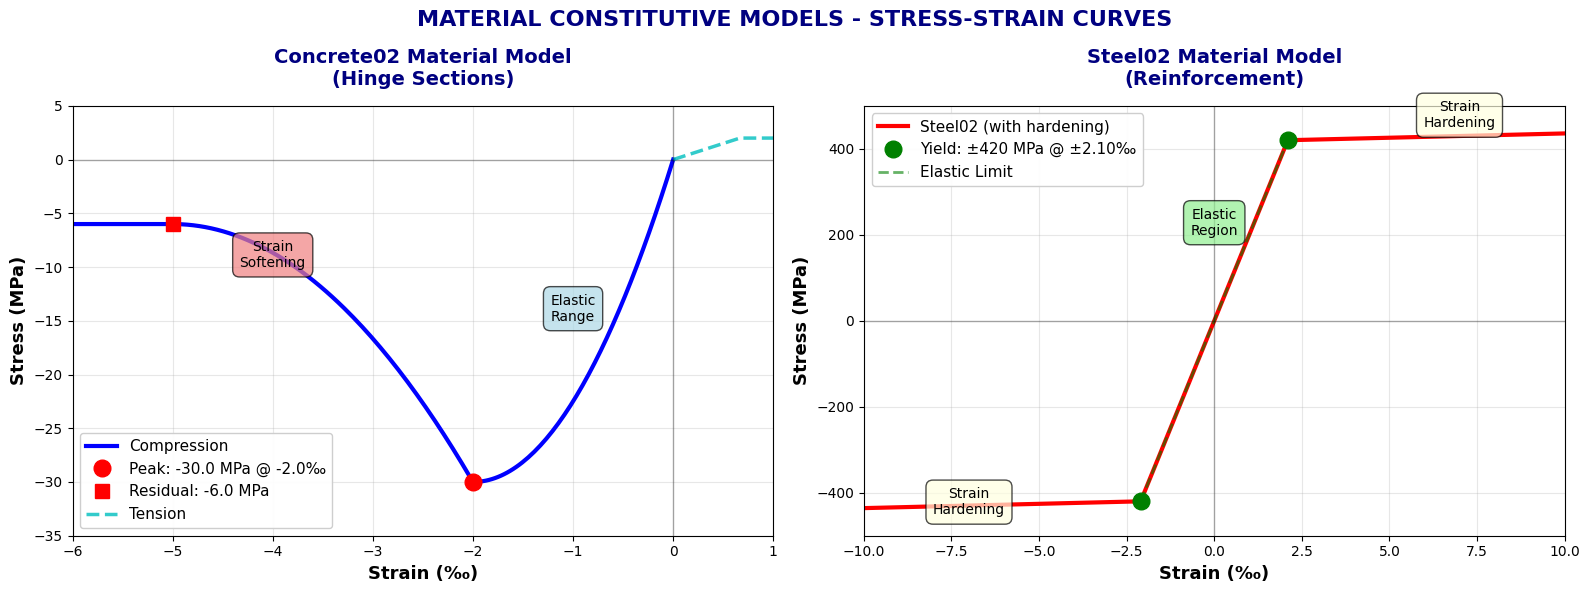


GRAVITY ANALYSIS
  Load per node: 200 kN
  Total gravity load: 1200 kN
  ✓ Analysis converged
  Roof vertical deflection: -0.37 mm


PUSHOVER ANALYSIS
  Target drift ratio: 4.0%
  Target displacement: 240.0 mm

  Running pushover (150 steps)...
  Step     Disp(mm)     Drift(%)     Shear(kN)   
  ------------------------------------------------
  15       24.00        0.400        152.6       


WARNING can't set handler after analysis is created


  30       48.00        0.800        230.6       
  45       72.00        1.200        252.1       
  60       96.00        1.600        259.0       
  75       120.00       2.000        261.5       
  90       144.00       2.400        260.9       


after: 100 iterations  current Norm: 0.0611154 (max: 1e-06, Norm deltaR: 352664)
NewtonRaphson::solveCurrentStep() -the ConvergenceTest object failed in test()
StaticAnalysis::analyze() - the Algorithm failed at step: 0 with domain at load factor 28933.8
OpenSees > analyze failed, returned: -3 error flag
after: 100 iterations  current Norm: 1.36448e-06 (max: 1e-06, Norm deltaR: 943.045)
ModifiedNewton::solveCurrentStep() -the ConvergenceTest object failed in test()
StaticAnalysis::analyze() - the Algorithm failed at step: 0 with domain at load factor 28896.9
OpenSees > analyze failed, returned: -3 error flag


  105      168.00       2.800        250.4       
  120      192.00       3.200        241.5       
  135      216.00       3.600        238.5       
  150      240.00       4.000        233.9       
  ------------------------------------------------
  ✓ Analysis completed: 150 steps
  Maximum base shear: 261.5 kN
  Maximum displacement: 240.00 mm
  Maximum drift: 4.000%

✓ Results plots saved: opensees_output/pushover_results_professional.png


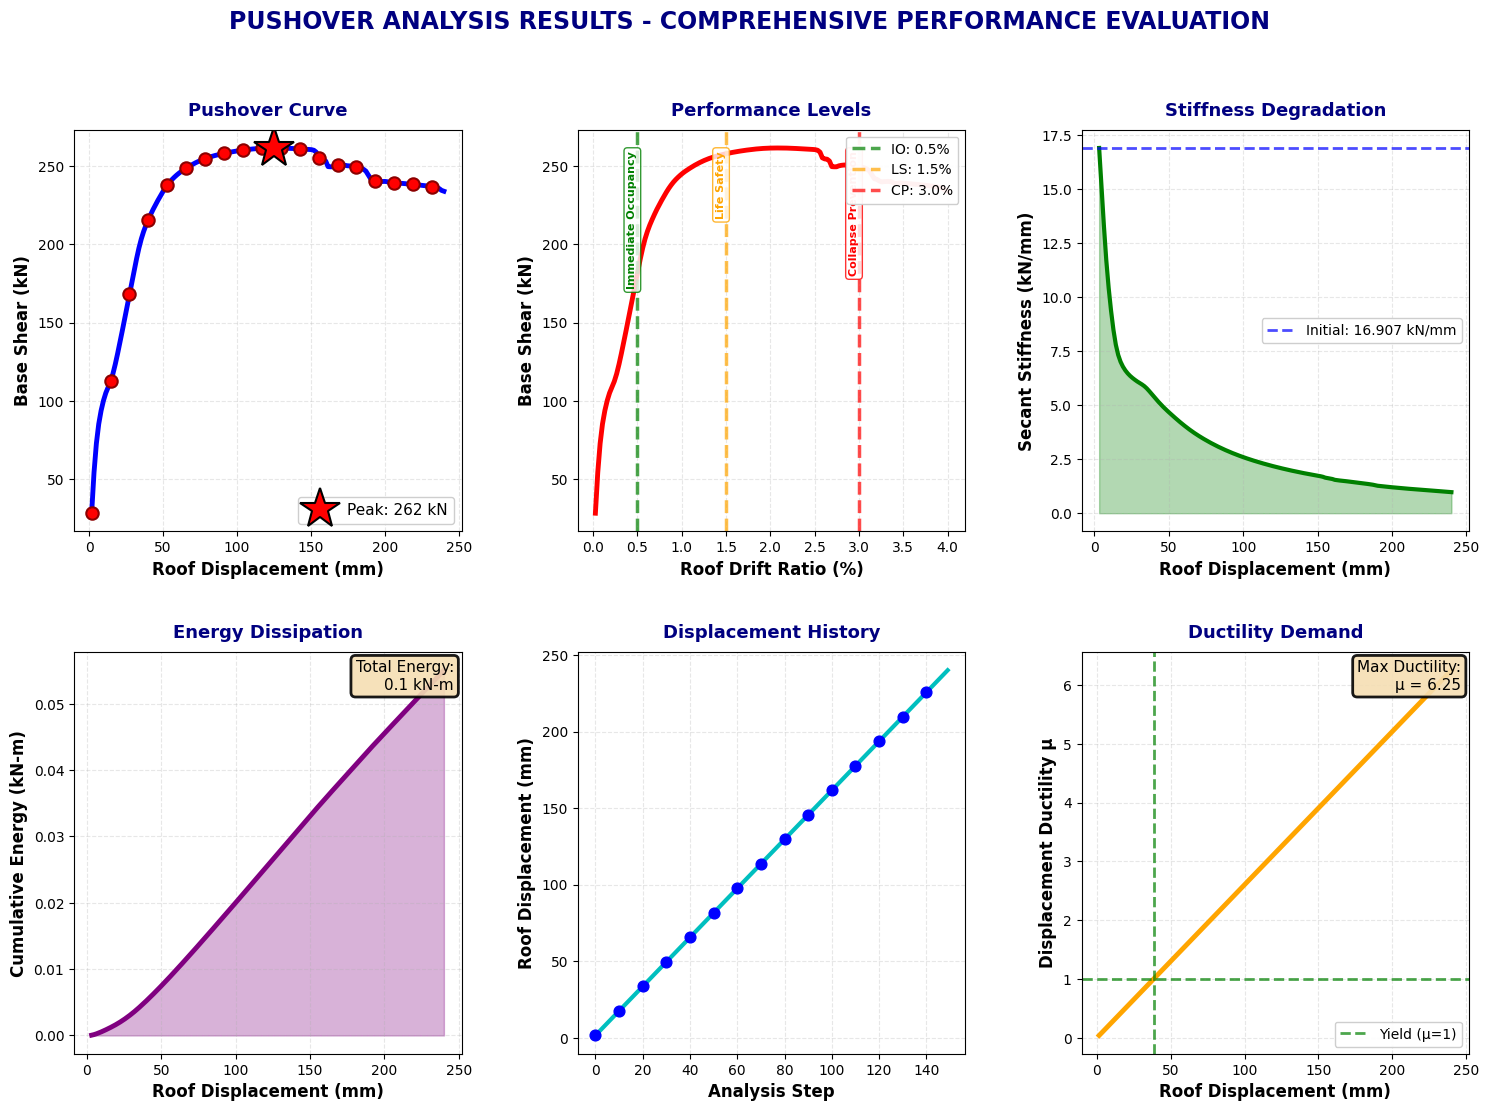

✓ Deformed shape saved: opensees_output/deformed_shape.png


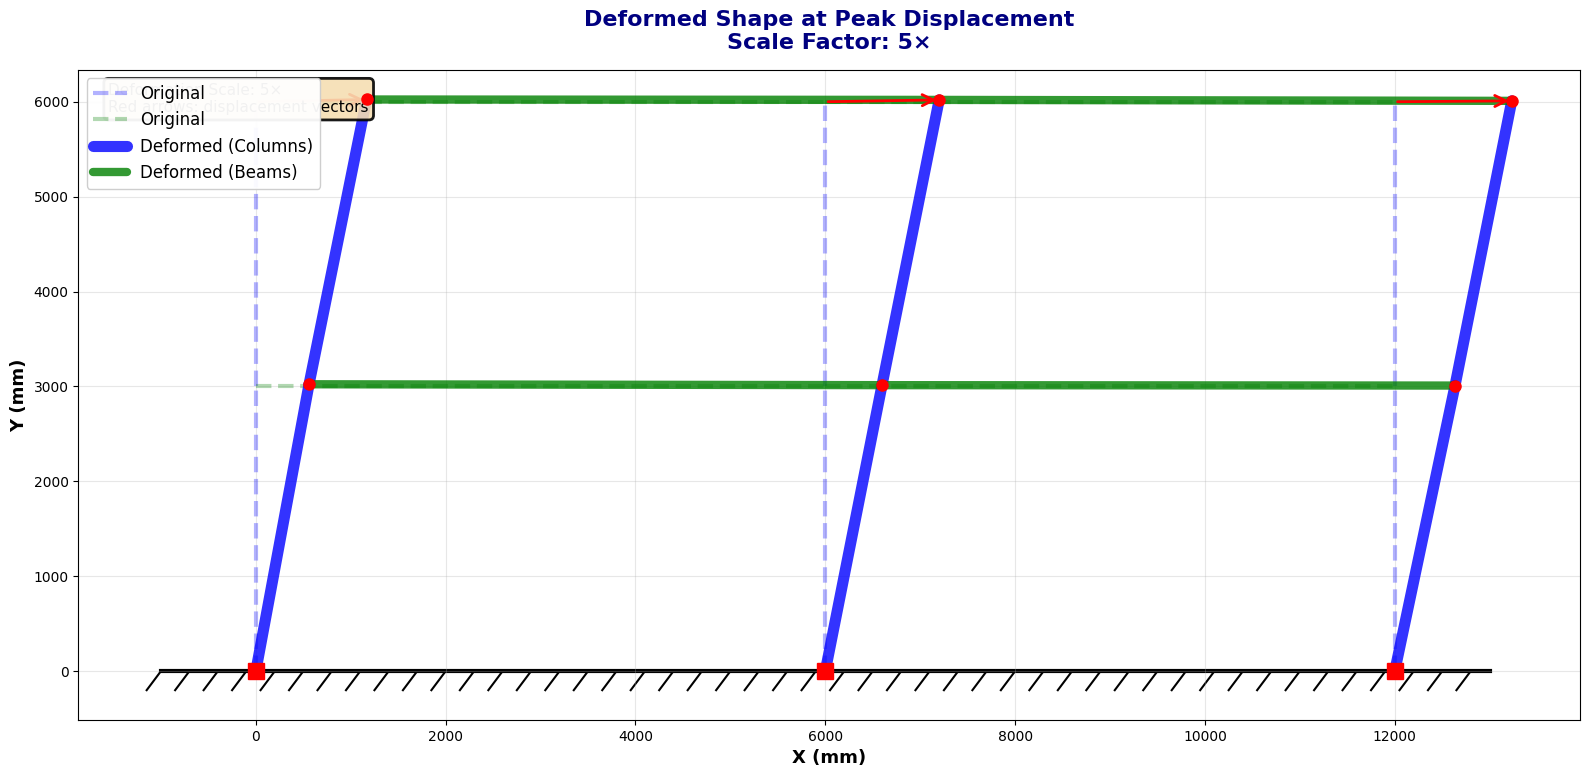


✓✓✓ PROFESSIONAL ANALYSIS COMPLETE ✓✓✓
All visualizations saved to: opensees_output



In [4]:
!pip install openseespy
!pip install matplotlib
!pip install numpy
# -*- coding: utf-8 -*-
"""
PROFESSIONAL PUSHOVER ANALYSIS - COMPREHENSIVE VISUALIZATION
- Fiber sections with realistic nonlinear behavior
- Clean professional plots with node/element numbering
- Deformed shape visualization
- Curvature distribution plots
- Material stress-strain curves
"""

import openseespy.opensees as ops
import matplotlib.pyplot as plt
from matplotlib.patches import Rectangle, Circle, FancyBboxPatch, Wedge
import matplotlib.patches as mpatches
from matplotlib.collections import LineCollection
import numpy as np
import os

# Create output directory
output_dir = 'opensees_output'
if not os.path.exists(output_dir):
    os.makedirs(output_dir)

print("\n" + "="*80)
print("PROFESSIONAL PUSHOVER ANALYSIS: 2-STORY RC FRAME")
print("Comprehensive Visualization Suite")
print("="*80 + "\n")

def build_frame():
    """Build frame with beamWithHinges elements using fiber sections"""

    ops.wipe()
    ops.model('basic', '-ndm', 2, '-ndf', 3)

    # --- GEOMETRY ---
    H = 3000.0      # Story height (mm)
    L = 6000.0      # Bay width (mm)
    n_stories = 2
    n_bays = 2

    print("GEOMETRY:")
    print(f"  Stories: {n_stories}, Bays: {n_bays}")
    print(f"  Story height: {H/1000:.1f} m, Bay width: {L/1000:.1f} m")

    # --- MATERIAL PROPERTIES ---
    fc = 30.0       # MPa (concrete)
    fy = 420.0      # MPa (steel)
    Es = 200000.0   # MPa (steel)
    E = 30000.0     # MPa (concrete - elastic)

    # Column 400x400 mm
    b_col = 400.0
    h_col = 400.0
    Ac = b_col * h_col
    Ic = b_col * h_col**3 / 12

    # Beam 300x500 mm
    b_beam = 300.0
    h_beam = 500.0
    Ab = b_beam * h_beam
    Ib = b_beam * h_beam**3 / 12

    print(f"\nSECTIONS:")
    print(f"  Column: {b_col:.0f}x{h_col:.0f} mm")
    print(f"  Beam: {b_beam:.0f}x{h_beam:.0f} mm")

    # --- MOMENT CAPACITIES (for reference) ---
    As_col = 8 * 314.0  # 8-D20 bars
    d_col = 360.0
    My_col = As_col * fy * (d_col - 40) / 1000000  # kN-m

    As_beam = 6 * 314.0  # 6-D20 bars
    d_beam = 460.0
    My_beam = As_beam * fy * (d_beam - 40) / 1000000  # kN-m

    print(f"\nCAPACITIES:")
    print(f"  Column My: {My_col:.1f} kN-m")
    print(f"  Beam My: {My_beam:.1f} kN-m")

    # --- CREATE NODES ---
    node_coords = {}
    node_tag = 1

    for floor in range(n_stories + 1):
        y = floor * H
        for bay in range(n_bays + 1):
            x = bay * L
            ops.node(node_tag, x, y)
            node_coords[node_tag] = (x, y)
            node_tag += 1

    print(f"\nNODES: {len(node_coords)}")

    # Fix base
    for i in range(1, n_bays + 2):
        ops.fix(i, 1, 1, 1)

    print(f"  Fixed base nodes: 1 to {n_bays+1}")

    # --- CREATE MATERIALS ---

    # Concrete material (Concrete02)
    fpc = -fc  # Negative for compression
    epsc0 = -0.002
    fpcu = -0.2 * fc
    epsU = -0.005
    lambda_val = 0.1
    ft = 2.0  # Tensile strength
    Ets = 0.1 * E  # Tension softening

    ops.uniaxialMaterial('Concrete02', 1, fpc, epsc0, fpcu, epsU, lambda_val, ft, Ets)

    # Steel material (Steel02)
    b = 0.01  # Strain hardening ratio
    R0 = 18.0
    cR1 = 0.925
    cR2 = 0.15

    ops.uniaxialMaterial('Steel02', 2, fy, Es, b, R0, cR1, cR2)

    print(f"\nMATERIALS:")
    print(f"  Concrete02: fc={fc:.0f} MPa")
    print(f"  Steel02: fy={fy:.0f} MPa")

    # --- CREATE FIBER SECTIONS ---

    # Column section (400x400 with 8-D20)
    sec_col = 1
    nf_core_y = 16
    nf_core_z = 16
    nf_cover_y = 4
    nf_cover_z = 4

    # Cover concrete
    cover = 40.0

    # Core dimensions
    y_core = h_col / 2.0 - cover
    z_core = b_col / 2.0 - cover

    ops.section('Fiber', sec_col)

    # Concrete - confined core
    ops.patch('rect', 1, nf_core_z, nf_core_y, -z_core, -y_core, z_core, y_core)

    # Concrete - cover (top, bottom, left, right)
    ops.patch('rect', 1, nf_cover_z, nf_cover_y, -b_col/2, y_core, b_col/2, h_col/2)
    ops.patch('rect', 1, nf_cover_z, nf_cover_y, -b_col/2, -h_col/2, b_col/2, -y_core)
    ops.patch('rect', 1, nf_cover_z, nf_core_y, -b_col/2, -y_core, -z_core, y_core)
    ops.patch('rect', 1, nf_cover_z, nf_core_y, z_core, -y_core, b_col/2, y_core)

    # Steel - 8 bars
    bar_area = 314.0  # D20 bar area
    ops.layer('straight', 2, 3, bar_area, -z_core, -y_core, -z_core, y_core)
    ops.layer('straight', 2, 3, bar_area, z_core, -y_core, z_core, y_core)
    ops.layer('straight', 2, 1, bar_area, 0, -y_core, 0, y_core)

    print(f"  Column section {sec_col} created (Fiber)")

    # Beam section (300x500 with 6-D20 bottom)
    sec_beam = 2

    # Beam core
    y_core_beam = h_beam / 2.0 - cover
    z_core_beam = b_beam / 2.0 - cover

    ops.section('Fiber', sec_beam)

    # Concrete - core
    ops.patch('rect', 1, 12, 20, -z_core_beam, -y_core_beam, z_core_beam, y_core_beam)

    # Concrete - cover
    ops.patch('rect', 1, 4, 4, -b_beam/2, y_core_beam, b_beam/2, h_beam/2)
    ops.patch('rect', 1, 4, 4, -b_beam/2, -h_beam/2, b_beam/2, -y_core_beam)
    ops.patch('rect', 1, 4, 20, -b_beam/2, -y_core_beam, -z_core_beam, y_core_beam)
    ops.patch('rect', 1, 4, 20, z_core_beam, -y_core_beam, b_beam/2, y_core_beam)

    # Steel - 6 bars at bottom
    ops.layer('straight', 2, 6, bar_area, -z_core_beam, -y_core_beam, z_core_beam, -y_core_beam)

    print(f"  Beam section {sec_beam} created (Fiber)")

    # --- ELASTIC SECTIONS FOR MIDDLE REGION ---

    # Elastic column section
    sec_col_elastic = 3
    ops.section('Elastic', sec_col_elastic, E, Ac, Ic)

    # Elastic beam section
    sec_beam_elastic = 4
    ops.section('Elastic', sec_beam_elastic, E, Ab, Ib)

    print(f"  Elastic sections: {sec_col_elastic} (column), {sec_beam_elastic} (beam)")

    # --- GEOMETRIC TRANSFORMATIONS ---
    ops.geomTransf('PDelta', 1)
    ops.geomTransf('Linear', 2)

    # --- CREATE ELEMENTS ---
    elem_tag = 1

    elements_info = []
    hinge_info = []

    print(f"\nCREATING ELEMENTS:")

    # Hinge lengths (10% of member length)
    Lp_col = 0.1 * H
    Lp_beam = 0.1 * L

    nip = 5  # Integration points

    # --- COLUMNS ---
    col_count = 0
    for story in range(n_stories):
        for bay in range(n_bays + 1):
            node_i = story * (n_bays + 1) + bay + 1
            node_j = (story + 1) * (n_bays + 1) + bay + 1

            xi, yi = node_coords[node_i]
            xj, yj = node_coords[node_j]

            # beamWithHinges element with fiber sections
            ops.element('beamWithHinges', elem_tag, node_i, node_j,
                       sec_col, Lp_col,      # Bottom hinge
                       sec_col, Lp_col,      # Top hinge
                       E, Ac, Ic, 1,
                       '-integration', 'Lobatto', sec_col_elastic, nip)

            elements_info.append({
                'tag': elem_tag,
                'type': 'column',
                'nodes': (node_i, node_j),
                'coords': ((xi, yi), (xj, yj))
            })

            # Record hinge locations - offset from nodes
            hinge_offset = Lp_col
            hinge_info.append({
                'type': 'column_hinge',
                'location': (xi, yi + hinge_offset),
                'element': elem_tag,
                'end': 'bottom'
            })
            hinge_info.append({
                'type': 'column_hinge',
                'location': (xj, yj - hinge_offset),
                'element': elem_tag,
                'end': 'top'
            })

            elem_tag += 1
            col_count += 1

    print(f"  Columns: {col_count}")

    # --- BEAMS ---
    beam_count = 0
    for floor in range(1, n_stories + 1):
        for bay in range(n_bays):
            node_i = floor * (n_bays + 1) + bay + 1
            node_j = floor * (n_bays + 1) + bay + 2

            xi, yi = node_coords[node_i]
            xj, yj = node_coords[node_j]

            ops.element('beamWithHinges', elem_tag, node_i, node_j,
                       sec_beam, Lp_beam,
                       sec_beam, Lp_beam,
                       E, Ab, Ib, 2,
                       '-integration', 'Lobatto', sec_beam_elastic, nip)

            elements_info.append({
                'tag': elem_tag,
                'type': 'beam',
                'nodes': (node_i, node_j),
                'coords': ((xi, yi), (xj, yj))
            })

            # Record hinge locations - offset from nodes
            hinge_offset = Lp_beam
            hinge_info.append({
                'type': 'beam_hinge',
                'location': (xi + hinge_offset, yi),
                'element': elem_tag,
                'end': 'left'
            })
            hinge_info.append({
                'type': 'beam_hinge',
                'location': (xj - hinge_offset, yj),
                'element': elem_tag,
                'end': 'right'
            })

            elem_tag += 1
            beam_count += 1

    print(f"  Beams: {beam_count}")
    print(f"  Total hinge zones: {len(hinge_info)}")

    # --- MASSES ---
    floor_mass = 200000.0  # kg
    mass_per_node = floor_mass / (n_bays + 1)

    for floor in range(1, n_stories + 1):
        for bay in range(n_bays + 1):
            node = floor * (n_bays + 1) + bay + 1
            ops.mass(node, mass_per_node, mass_per_node, 0.0)

    print(f"\nMASSES:")
    print(f"  Per floor: {floor_mass/1000:.1f} tonnes")
    print(f"  Per node: {mass_per_node/1000:.2f} tonnes")

    return {
        'H': H, 'L': L,
        'n_stories': n_stories, 'n_bays': n_bays,
        'node_coords': node_coords,
        'elements_info': elements_info,
        'hinge_info': hinge_info,
        'b_col': b_col, 'h_col': h_col,
        'b_beam': b_beam, 'h_beam': h_beam,
        'My_col': My_col, 'My_beam': My_beam,
        'Lp_col': Lp_col, 'Lp_beam': Lp_beam,
        'fc': fc, 'fy': fy, 'Es': Es, 'E': E
    }

def draw_section(ax, b, h, x, y, section_type, label):
    """Draw detailed cross-section"""

    rect = Rectangle((x - b/2, y - h/2), b, h,
                     edgecolor='black', facecolor='lightgray', linewidth=2.5)
    ax.add_patch(rect)

    # Cover outline
    cover = 40
    rect_core = Rectangle((x - b/2 + cover, y - h/2 + cover),
                          b - 2*cover, h - 2*cover,
                          edgecolor='blue', facecolor='none',
                          linewidth=1.5, linestyle='--', alpha=0.6)
    ax.add_patch(rect_core)

    if section_type == 'column':
        # 8 bars in column
        positions = [
            (-b/2 + cover, -h/2 + cover), (0, -h/2 + cover), (b/2 - cover, -h/2 + cover),
            (-b/2 + cover, 0), (b/2 - cover, 0),
            (-b/2 + cover, h/2 - cover), (0, h/2 - cover), (b/2 - cover, h/2 - cover)
        ]
        for px, py in positions:
            circle = Circle((x + px, y + py), 12, color='darkred', zorder=10,
                          edgecolor='black', linewidth=0.5)
            ax.add_patch(circle)
    else:
        # 6 bars at bottom of beam
        y_bars = y - h/2 + cover
        x_positions = np.linspace(x - b/2 + cover, x + b/2 - cover, 6)
        for px in x_positions:
            circle = Circle((px, y_bars), 12, color='darkred', zorder=10,
                          edgecolor='black', linewidth=0.5)
            ax.add_patch(circle)

    # Dimensions
    ax.text(x, y - h/2 - 100, f'b = {b:.0f} mm', ha='center',
           fontsize=10, fontweight='bold', color='darkblue')
    ax.text(x - b/2 - 120, y, f'h = {h:.0f} mm', va='center', rotation=90,
           fontsize=10, fontweight='bold', color='darkblue')
    ax.text(x, y + h/2 + 120, label, ha='center', fontsize=12,
           fontweight='bold', color='navy',
           bbox=dict(boxstyle='round,pad=0.5', facecolor='lightyellow',
                    edgecolor='navy', linewidth=2))

    ax.set_aspect('equal')
    ax.grid(True, alpha=0.2, linestyle=':')

def visualize_model(model_data):
    """Professional model visualization with numbering"""

    node_coords = model_data['node_coords']
    elements_info = model_data['elements_info']
    hinge_info = model_data['hinge_info']
    H = model_data['H']
    L = model_data['L']
    n_stories = model_data['n_stories']
    n_bays = model_data['n_bays']

    fig = plt.figure(figsize=(20, 14))
    gs = fig.add_gridspec(3, 3, hspace=0.35, wspace=0.35,
                         left=0.08, right=0.95, top=0.93, bottom=0.05)

    ax_main = fig.add_subplot(gs[:, :2])
    ax_col = fig.add_subplot(gs[0, 2])
    ax_beam = fig.add_subplot(gs[1, 2])
    ax_info = fig.add_subplot(gs[2, 2])
    ax_info.axis('off')

    # --- DRAW ELEMENTS ---
    for elem in elements_info:
        (x1, y1), (x2, y2) = elem['coords']

        if elem['type'] == 'column':
            ax_main.plot([x1, x2], [y1, y2], 'b-', linewidth=12,
                        solid_capstyle='round', alpha=0.7, zorder=2)
        else:
            ax_main.plot([x1, x2], [y1, y2], 'g-', linewidth=10,
                        solid_capstyle='round', alpha=0.7, zorder=2)

    # --- DRAW HINGE ZONES ---
    hinge_drawn = {'column': False, 'beam': False}
    for hinge in hinge_info:
        x, y = hinge['location']

        if 'column' in hinge['type']:
            color = 'red'
            size = 120
            label = 'Column Hinge Zone' if not hinge_drawn['column'] else ''
            hinge_drawn['column'] = True
            marker_style = 'o'
        else:
            color = 'orange'
            size = 100
            label = 'Beam Hinge Zone' if not hinge_drawn['beam'] else ''
            hinge_drawn['beam'] = True
            marker_style = 's'

        # Hinge marker
        ax_main.scatter(x, y, s=size*3, c=color, marker=marker_style,
                       zorder=10, alpha=0.6, edgecolors='darkred',
                       linewidths=2, label=label)

        # Crosshair
        s = 80
        ax_main.plot([x-s, x+s], [y, y], 'k-', linewidth=1.5, zorder=11, alpha=0.7)
        ax_main.plot([x, x], [y-s, y+s], 'k-', linewidth=1.5, zorder=11, alpha=0.7)

    # --- DRAW NODES WITH NUMBERS ---
    for node, (x, y) in node_coords.items():
        if y == 0:
            # Base nodes - fixed support
            ax_main.plot(x, y, 'ks', markersize=14, zorder=15,
                        markeredgewidth=2, markeredgecolor='red')
            # Support symbol
            triangle = mpatches.Polygon([[x-200, y], [x+200, y], [x, y-300]],
                                       closed=True, facecolor='gray',
                                       edgecolor='black', linewidth=2, zorder=14)
            ax_main.add_patch(triangle)
        else:
            ax_main.plot(x, y, 'ko', markersize=10, zorder=15,
                        markeredgewidth=2, markerfacecolor='white')

        # Node numbers - positioned to avoid overlap
        if y == 0:
            offset_y = -500
        else:
            offset_y = 250

        ax_main.text(x, y + offset_y, f'{node}', ha='center', va='center',
                    fontsize=9, fontweight='bold', color='white',
                    bbox=dict(boxstyle='circle,pad=0.3', facecolor='darkblue',
                             edgecolor='white', linewidth=1.5),
                    zorder=16)

    # --- ELEMENT NUMBERS ---
    for elem in elements_info:
        (x1, y1), (x2, y2) = elem['coords']
        xm, ym = (x1 + x2) / 2, (y1 + y2) / 2

        # Offset element numbers from centerline
        if elem['type'] == 'column':
            offset_x = 350
            offset_y = 0
            bg_color = 'lightblue'
        else:
            offset_x = 0
            offset_y = 350
            bg_color = 'lightgreen'

        ax_main.text(xm + offset_x, ym + offset_y, f"E{elem['tag']}",
                    ha='center', va='center',
                    fontsize=8, fontweight='bold', color='black',
                    bbox=dict(boxstyle='round,pad=0.4', facecolor=bg_color,
                             edgecolor='black', linewidth=1.5, alpha=0.9),
                    zorder=16)

    # --- GROUND REPRESENTATION ---
    ground_x = [-1000, n_bays * L + 1000]
    ax_main.plot(ground_x, [0, 0], 'k-', linewidth=4, zorder=1)
    for i in range(int(ground_x[0]), int(ground_x[1]), 250):
        ax_main.plot([i, i-120], [0, -180], 'k-', linewidth=2, zorder=1)

    # --- AXES AND LABELS ---
    ax_main.set_xlabel('X Coordinate (mm)', fontsize=14, fontweight='bold')
    ax_main.set_ylabel('Y Coordinate (mm)', fontsize=14, fontweight='bold')
    ax_main.set_title('Structural Model - Node & Element Numbering\nPlastic Hinge Locations',
                     fontsize=16, fontweight='bold', pad=20, color='navy')
    ax_main.legend(loc='upper left', fontsize=11, framealpha=0.95,
                  edgecolor='black', fancybox=True, shadow=True)
    ax_main.grid(True, alpha=0.3, linestyle='--')
    ax_main.set_aspect('equal')
    ax_main.set_xlim(-1500, n_bays * L + 1500)
    ax_main.set_ylim(-1200, n_stories * H + 1200)

    # Add coordinate system
    arrow_props = dict(arrowstyle='->', lw=3, color='red')
    ax_main.annotate('', xy=(500, -800), xytext=(-500, -800),
                    arrowprops=arrow_props)
    ax_main.text(0, -1000, 'X', fontsize=14, fontweight='bold',
                ha='center', color='red')
    ax_main.annotate('', xy=(-1200, 500), xytext=(-1200, -500),
                    arrowprops=arrow_props)
    ax_main.text(-1400, 0, 'Y', fontsize=14, fontweight='bold',
                ha='center', color='red')

    # --- CROSS SECTIONS ---
    draw_section(ax_col, model_data['b_col'], model_data['h_col'],
                0, 0, 'column', 'COLUMN SECTION\n400×400 mm\n8-D20 bars')
    ax_col.set_xlim(-350, 350)
    ax_col.set_ylim(-350, 450)
    ax_col.set_title('Column Cross-Section', fontsize=12, fontweight='bold',
                    color='navy', pad=10)
    ax_col.set_xlabel('z (mm)', fontsize=10)
    ax_col.set_ylabel('y (mm)', fontsize=10)

    draw_section(ax_beam, model_data['b_beam'], model_data['h_beam'],
                0, 0, 'beam', 'BEAM SECTION\n300×500 mm\n6-D20 bars')
    ax_beam.set_xlim(-300, 300)
    ax_beam.set_ylim(-400, 500)
    ax_beam.set_title('Beam Cross-Section', fontsize=12, fontweight='bold',
                     color='navy', pad=10)
    ax_beam.set_xlabel('z (mm)', fontsize=10)
    ax_beam.set_ylabel('y (mm)', fontsize=10)

    # --- INFO PANEL ---
    col_hinges = len([h for h in hinge_info if 'column' in h['type']])
    beam_hinges = len([h for h in hinge_info if 'beam' in h['type']])

    info_text = f"""
╔═══════════════════════════════════════╗
║         MODEL SUMMARY                 ║
╚═══════════════════════════════════════╝

GEOMETRY:
  • Stories: {n_stories}
  • Bays: {n_bays}
  • Story Height: {H/1000:.1f} m
  • Bay Width: {L/1000:.1f} m

ELEMENTS:
  • Total Nodes: {len(node_coords)}
  • Columns: {n_stories * (n_bays + 1)}
  • Beams: {n_stories * n_bays}
  • Element Type: beamWithHinges

PLASTIC HINGES:
  • Column Hinge Zones: {col_hinges}
  • Beam Hinge Zones: {beam_hinges}
  • Total: {len(hinge_info)}
  • Hinge Length (Col): {model_data['Lp_col']:.0f} mm
  • Hinge Length (Beam): {model_data['Lp_beam']:.0f} mm

SECTION PROPERTIES:
  • Column: {model_data['b_col']:.0f}×{model_data['h_col']:.0f} mm
  • Beam: {model_data['b_beam']:.0f}×{model_data['h_beam']:.0f} mm

MOMENT CAPACITIES:
  • Column My: {model_data['My_col']:.1f} kN-m
  • Beam My: {model_data['My_beam']:.1f} kN-m

MATERIALS:
  • Concrete fc: {model_data['fc']:.0f} MPa
  • Steel fy: {model_data['fy']:.0f} MPa
    """

    ax_info.text(0.05, 0.98, info_text, transform=ax_info.transAxes,
                fontsize=9, verticalalignment='top', family='monospace',
                bbox=dict(boxstyle='round,pad=0.8', facecolor='wheat', alpha=0.95,
                         edgecolor='navy', linewidth=3))

    plt.suptitle('PROFESSIONAL STRUCTURAL MODEL VISUALIZATION',
                fontsize=18, fontweight='bold', y=0.97, color='navy')

    output_path = os.path.join(output_dir, 'model_visualization_professional.png')
    plt.savefig(output_path, dpi=200, bbox_inches='tight', facecolor='white')
    print(f"\n✓ Model visualization saved: {output_path}")
    plt.show()
    plt.close()

def plot_stress_strain_curves(model_data):
    """Plot material stress-strain curves"""

    fc = model_data['fc']
    fy = model_data['fy']
    Es = model_data['Es']

    fig, axes = plt.subplots(1, 2, figsize=(16, 6))

    # --- CONCRETE STRESS-STRAIN ---
    ax = axes[0]

    # Compression
    eps_c = np.linspace(0, -0.006, 200)
    sigma_c = []

    epsc0 = -0.002
    fpc = -fc

    for eps in eps_c:
        if eps >= epsc0:
            # Ascending branch
            ratio = eps / epsc0
            sigma = fpc * (2 * ratio - ratio**2)
        else:
            # Descending branch
            epsU = -0.005
            fpcu = -0.2 * fc
            if eps >= epsU:
                sigma = fpcu + (fpc - fpcu) * ((eps - epsU) / (epsc0 - epsU))**2
            else:
                sigma = fpcu
        sigma_c.append(sigma)

    ax.plot(eps_c * 1000, sigma_c, 'b-', linewidth=3, label='Compression')

    # Key points
    ax.plot(epsc0 * 1000, fpc, 'ro', markersize=12, label=f'Peak: {fpc:.1f} MPa @ {epsc0*1000:.1f}‰')
    ax.plot(-5, -0.2*fc, 'rs', markersize=10, label=f'Residual: {-0.2*fc:.1f} MPa')

    # Tension (simplified)
    eps_t = np.linspace(0, 0.001, 50)
    ft = 2.0
    Ets = 0.1 * model_data['E']
    sigma_t = np.minimum(ft, Ets * eps_t)

    ax.plot(eps_t * 1000, sigma_t, 'c--', linewidth=2.5, label='Tension', alpha=0.8)

    ax.axhline(y=0, color='k', linewidth=1, linestyle='-', alpha=0.3)
    ax.axvline(x=0, color='k', linewidth=1, linestyle='-', alpha=0.3)
    ax.grid(True, alpha=0.3)
    ax.set_xlabel('Strain (‰)', fontsize=13, fontweight='bold')
    ax.set_ylabel('Stress (MPa)', fontsize=13, fontweight='bold')
    ax.set_title('Concrete02 Material Model\n(Hinge Sections)',
                fontsize=14, fontweight='bold', color='navy', pad=15)
    ax.legend(fontsize=11, loc='lower left', framealpha=0.95)
    ax.set_xlim(-6, 1)
    ax.set_ylim(-35, 5)

    # Add annotations
    ax.annotate('Elastic\nRange', xy=(-1, -15), fontsize=10, ha='center',
               bbox=dict(boxstyle='round,pad=0.5', facecolor='lightblue', alpha=0.7))
    ax.annotate('Strain\nSoftening', xy=(-4, -10), fontsize=10, ha='center',
               bbox=dict(boxstyle='round,pad=0.5', facecolor='lightcoral', alpha=0.7))

    # --- STEEL STRESS-STRAIN ---
    ax = axes[1]

    eps_s = np.linspace(-0.01, 0.01, 400)
    sigma_s = []

    eps_y = fy / Es
    b = 0.01  # Strain hardening

    for eps in eps_s:
        if abs(eps) <= eps_y:
            sigma = Es * eps
        else:
            if eps > eps_y:
                sigma = fy + b * Es * (eps - eps_y)
            else:
                sigma = -fy + b * Es * (eps + eps_y)
        sigma_s.append(sigma)

    ax.plot(eps_s * 1000, sigma_s, 'r-', linewidth=3, label='Steel02 (with hardening)')

    # Yield points
    ax.plot(eps_y * 1000, fy, 'go', markersize=12,
           label=f'Yield: ±{fy:.0f} MPa @ ±{eps_y*1000:.2f}‰', zorder=5)
    ax.plot(-eps_y * 1000, -fy, 'go', markersize=12, zorder=5)

    # Elastic limit lines
    ax.plot([-eps_y*1000, eps_y*1000], [-fy, fy], 'g--',
           linewidth=2, alpha=0.6, label='Elastic Limit')

    ax.axhline(y=0, color='k', linewidth=1, linestyle='-', alpha=0.3)
    ax.axvline(x=0, color='k', linewidth=1, linestyle='-', alpha=0.3)
    ax.grid(True, alpha=0.3)
    ax.set_xlabel('Strain (‰)', fontsize=13, fontweight='bold')
    ax.set_ylabel('Stress (MPa)', fontsize=13, fontweight='bold')
    ax.set_title('Steel02 Material Model\n(Reinforcement)',
                fontsize=14, fontweight='bold', color='navy', pad=15)
    ax.legend(fontsize=11, loc='upper left', framealpha=0.95)
    ax.set_xlim(-10, 10)
    ax.set_ylim(-500, 500)

    # Add annotations
    ax.annotate('Elastic\nRegion', xy=(0, 200), fontsize=10, ha='center',
               bbox=dict(boxstyle='round,pad=0.5', facecolor='lightgreen', alpha=0.7))
    ax.annotate('Strain\nHardening', xy=(7, 450), fontsize=10, ha='center',
               bbox=dict(boxstyle='round,pad=0.5', facecolor='lightyellow', alpha=0.7))
    ax.annotate('Strain\nHardening', xy=(-7, -450), fontsize=10, ha='center',
               bbox=dict(boxstyle='round,pad=0.5', facecolor='lightyellow', alpha=0.7))

    plt.suptitle('MATERIAL CONSTITUTIVE MODELS - STRESS-STRAIN CURVES',
                fontsize=16, fontweight='bold', color='navy')
    plt.tight_layout()

    output_path = os.path.join(output_dir, 'material_stress_strain.png')
    plt.savefig(output_path, dpi=200, bbox_inches='tight', facecolor='white')
    print(f"✓ Stress-strain curves saved: {output_path}")
    plt.show()
    plt.close()

def run_gravity(n_stories, n_bays):
    """Gravity analysis"""

    print(f"\n{'='*80}")
    print("GRAVITY ANALYSIS")
    print(f"{'='*80}")

    P = 200.0  # kN

    ops.timeSeries('Constant', 1)
    ops.pattern('Plain', 1, 1)

    total = 0
    for floor in range(1, n_stories + 1):
        for bay in range(n_bays + 1):
            node = floor * (n_bays + 1) + bay + 1
            ops.load(node, 0.0, -P * 1000, 0.0)
            total += P

    print(f"  Load per node: {P:.0f} kN")
    print(f"  Total gravity load: {total:.0f} kN")

    ops.constraints('Transformation')
    ops.numberer('RCM')
    ops.system('BandGeneral')
    ops.test('NormDispIncr', 1.0e-8, 100)
    ops.algorithm('Newton')
    ops.integrator('LoadControl', 0.1)
    ops.analysis('Static')

    ok = ops.analyze(10)

    if ok == 0:
        print("  ✓ Analysis converged")
        roof = n_stories * (n_bays + 1) + 2
        disp = ops.nodeDisp(roof, 2)
        print(f"  Roof vertical deflection: {disp:.2f} mm")
    else:
        print("  ✗ Analysis failed")

    ops.loadConst('-time', 0.0)
    print(f"{'='*80}\n")

def run_pushover(H, n_stories, n_bays, elements_info):
    """Pushover analysis with detailed recording"""

    print(f"\n{'='*80}")
    print("PUSHOVER ANALYSIS")
    print(f"{'='*80}")

    target_drift = 0.04
    target_disp = target_drift * n_stories * H

    print(f"  Target drift ratio: {target_drift*100:.1f}%")
    print(f"  Target displacement: {target_disp:.1f} mm")

    ops.timeSeries('Linear', 2)
    ops.pattern('Plain', 2, 2)

    # Lateral loads proportional to floor height
    for floor in range(1, n_stories + 1):
        for bay in range(n_bays + 1):
            node = floor * (n_bays + 1) + bay + 1
            ops.load(node, floor * 1.0, 0.0, 0.0)

    control_node = n_stories * (n_bays + 1) + 2

    ops.constraints('Transformation')
    ops.numberer('RCM')
    ops.system('BandGeneral')
    ops.test('NormDispIncr', 1.0e-6, 100, 0)
    ops.algorithm('Newton')

    num_steps = 150
    disp_incr = target_disp / num_steps

    ops.integrator('DisplacementControl', control_node, 1, disp_incr)
    ops.analysis('Static')

    # Data recording
    roof_disp = []
    base_shear = []
    element_curvatures = {elem['tag']: [] for elem in elements_info}
    step_data = []

    print(f"\n  Running pushover (150 steps)...")
    print(f"  {'Step':<8} {'Disp(mm)':<12} {'Drift(%)':<12} {'Shear(kN)':<12}")
    print(f"  {'-'*48}")

    for step in range(num_steps):
        ok = ops.analyze(1)

        # Try alternative algorithms if convergence fails
        if ok != 0:
            ops.algorithm('ModifiedNewton', '-initial')
            ok = ops.analyze(1)
            ops.algorithm('Newton')

        if ok != 0:
            ops.algorithm('NewtonLineSearch')
            ok = ops.analyze(1)
            ops.algorithm('Newton')

        if ok != 0:
            print(f"  ✗ Convergence failed at step {step+1}")
            break

        # Record displacement
        disp = ops.nodeDisp(control_node, 1)
        roof_disp.append(disp)

        # Calculate base shear
        ops.reactions()
        V = 0.0
        for bay in range(n_bays + 1):
            V += ops.nodeReaction(bay + 1, 1)

        base_shear.append(abs(V) / 1000)

        # Record element curvatures
        for elem in elements_info:
            try:
                # Get section forces at integration points
                forces = ops.eleResponse(elem['tag'], 'section', '1', 'deformation')
                if forces and len(forces) >= 3:
                    curvature = forces[2]  # Curvature is 3rd component
                    element_curvatures[elem['tag']].append(abs(curvature))
                else:
                    element_curvatures[elem['tag']].append(0.0)
            except:
                element_curvatures[elem['tag']].append(0.0)

        # Store step data
        step_data.append({
            'step': step + 1,
            'disp': disp,
            'drift': disp / (n_stories * H) * 100,
            'shear': base_shear[-1]
        })

        # Print progress
        if (step + 1) % 15 == 0:
            drift = disp / (n_stories * H) * 100
            print(f"  {step+1:<8} {disp:<12.2f} {drift:<12.3f} {base_shear[-1]:<12.1f}")

    print(f"  {'-'*48}")
    print(f"  ✓ Analysis completed: {len(roof_disp)} steps")
    if len(base_shear) > 0:
        print(f"  Maximum base shear: {max(base_shear):.1f} kN")
        print(f"  Maximum displacement: {max(roof_disp):.2f} mm")
        print(f"  Maximum drift: {max(roof_disp)/(n_stories*H)*100:.3f}%")
    print(f"{'='*80}\n")

    return (np.array(roof_disp), np.array(base_shear),
            element_curvatures, step_data)

def plot_deformed_shape(model_data, scale_factor=50):
    """Plot deformed shape at peak displacement"""

    node_coords = model_data['node_coords']
    elements_info = model_data['elements_info']
    n_stories = model_data['n_stories']
    n_bays = model_data['n_bays']
    H = model_data['H']
    L = model_data['L']

    fig, ax = plt.subplots(figsize=(16, 10))

    # Get deformed coordinates
    deformed_coords = {}
    for node in node_coords.keys():
        x_orig, y_orig = node_coords[node]
        try:
            u_x = ops.nodeDisp(node, 1) * scale_factor
            u_y = ops.nodeDisp(node, 2) * scale_factor
            deformed_coords[node] = (x_orig + u_x, y_orig + u_y)
        except:
            deformed_coords[node] = (x_orig, y_orig)

    # Draw original shape (light)
    for elem in elements_info:
        (x1, y1), (x2, y2) = elem['coords']
        if elem['type'] == 'column':
            ax.plot([x1, x2], [y1, y2], 'b--', linewidth=3, alpha=0.3,
                   label='Original' if elem['tag'] == 1 else '')
        else:
            ax.plot([x1, x2], [y1, y2], 'g--', linewidth=3, alpha=0.3,
                   label='Original' if elem['tag'] == 7 else '')

    # Draw deformed shape
    for elem in elements_info:
        node_i, node_j = elem['nodes']
        x1, y1 = deformed_coords[node_i]
        x2, y2 = deformed_coords[node_j]

        if elem['type'] == 'column':
            ax.plot([x1, x2], [y1, y2], 'b-', linewidth=8, alpha=0.8,
                   solid_capstyle='round',
                   label='Deformed (Columns)' if elem['tag'] == 1 else '')
        else:
            ax.plot([x1, x2], [y1, y2], 'g-', linewidth=6, alpha=0.8,
                   solid_capstyle='round',
                   label='Deformed (Beams)' if elem['tag'] == 7 else '')

    # Draw deformed nodes
    for node, (x, y) in deformed_coords.items():
        if node_coords[node][1] == 0:  # Base nodes
            ax.plot(x, y, 'rs', markersize=12, zorder=10)
        else:
            ax.plot(x, y, 'ro', markersize=8, zorder=10)

    # Draw displacement vectors for top nodes
    for floor in range(1, n_stories + 1):
        for bay in range(n_bays + 1):
            node = floor * (n_bays + 1) + bay + 1
            x_orig, y_orig = node_coords[node]
            x_def, y_def = deformed_coords[node]

            if floor == n_stories:  # Only show for roof
                ax.annotate('', xy=(x_def, y_def), xytext=(x_orig, y_orig),
                          arrowprops=dict(arrowstyle='->', lw=2, color='red',
                                        mutation_scale=20))

    # Ground
    ground_x = [-1000, n_bays * L + 1000]
    ax.plot(ground_x, [0, 0], 'k-', linewidth=3, zorder=1)
    for i in range(int(ground_x[0]), int(ground_x[1]), 300):
        ax.plot([i, i-150], [0, -200], 'k-', linewidth=1.5, zorder=1)

    ax.set_xlabel('X (mm)', fontsize=13, fontweight='bold')
    ax.set_ylabel('Y (mm)', fontsize=13, fontweight='bold')
    ax.set_title(f'Deformed Shape at Peak Displacement\nScale Factor: {scale_factor}×',
                fontsize=16, fontweight='bold', color='navy', pad=15)
    ax.legend(fontsize=12, loc='upper left', framealpha=0.95)
    ax.grid(True, alpha=0.3)
    ax.set_aspect('equal')

    # Add scale info
    ax.text(0.02, 0.98, f'Deformation Scale: {scale_factor}×\nRed arrows: displacement vectors',
           transform=ax.transAxes, fontsize=11, verticalalignment='top',
           bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.9,
                    edgecolor='black', linewidth=2))

    plt.tight_layout()
    output_path = os.path.join(output_dir, 'deformed_shape.png')
    plt.savefig(output_path, dpi=200, bbox_inches='tight', facecolor='white')
    print(f"✓ Deformed shape saved: {output_path}")
    plt.show()
    plt.close()

def plot_curvature_distribution(element_curvatures, elements_info, model_data):
    """Plot curvature distribution along members"""

    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(18, 7))

    # Separate columns and beams
    column_elems = [e for e in elements_info if e['type'] == 'column']
    beam_elems = [e for e in elements_info if e['type'] == 'beam']

    # --- COLUMN CURVATURES ---
    colors_col = plt.cm.Reds(np.linspace(0.3, 0.9, len(column_elems)))

    for idx, elem in enumerate(column_elems):
        tag = elem['tag']
        curvatures = element_curvatures[tag]
        if len(curvatures) > 0:
            steps = np.arange(len(curvatures))
            ax1.plot(steps, np.array(curvatures) * 1000,
                    linewidth=2.5, color=colors_col[idx],
                    label=f'Column E{tag}', alpha=0.8)

    ax1.set_xlabel('Analysis Step', fontsize=13, fontweight='bold')
    ax1.set_ylabel('Curvature (×10⁻³ rad/mm)', fontsize=13, fontweight='bold')
    ax1.set_title('Column Curvature Evolution\n(Hinge Sections)',
                 fontsize=14, fontweight='bold', color='navy', pad=15)
    ax1.legend(fontsize=9, loc='upper left', ncol=2, framealpha=0.95)
    ax1.grid(True, alpha=0.3)

    # Add yield curvature reference (approximate)
    My_col = model_data['My_col'] * 1e6  # N-mm
    Ic = model_data['b_col'] * model_data['h_col']**3 / 12
    phi_y_col = My_col / (model_data['E'] * Ic) * 1000
    ax1.axhline(y=phi_y_col, color='red', linestyle='--', linewidth=2,
               label=f'Approx. Yield φy ≈ {phi_y_col:.3f}×10⁻³', alpha=0.7)
    ax1.legend(fontsize=9, loc='upper left', ncol=2, framealpha=0.95)

    # --- BEAM CURVATURES ---
    colors_beam = plt.cm.Greens(np.linspace(0.3, 0.9, len(beam_elems)))

    for idx, elem in enumerate(beam_elems):
        tag = elem['tag']
        curvatures = element_curvatures[tag]
        if len(curvatures) > 0:
            steps = np.arange(len(curvatures))
            ax2.plot(steps, np.array(curvatures) * 1000,
                    linewidth=2.5, color=colors_beam[idx],
                    label=f'Beam E{tag}', alpha=0.8)

    ax2.set_xlabel('Analysis Step', fontsize=13, fontweight='bold')
    ax2.set_ylabel('Curvature (×10⁻³ rad/mm)', fontsize=13, fontweight='bold')
    ax2.set_title('Beam Curvature Evolution\n(Hinge Sections)',
                 fontsize=14, fontweight='bold', color='navy', pad=15)
    ax2.legend(fontsize=9, loc='upper left', ncol=2, framealpha=0.95)
    ax2.grid(True, alpha=0.3)

    # Add yield curvature reference
    My_beam = model_data['My_beam'] * 1e6  # N-mm
    Ib = model_data['b_beam'] * model_data['h_beam']**3 / 12
    phi_y_beam = My_beam / (model_data['E'] * Ib) * 1000
    ax2.axhline(y=phi_y_beam, color='red', linestyle='--', linewidth=2,
               label=f'Approx. Yield φy ≈ {phi_y_beam:.3f}×10⁻³', alpha=0.7)
    ax2.legend(fontsize=9, loc='upper left', ncol=2, framealpha=0.95)

    plt.suptitle('CURVATURE DISTRIBUTION - HINGE SECTIONS',
                fontsize=16, fontweight='bold', color='navy')
    plt.tight_layout()

    output_path = os.path.join(output_dir, 'curvature_distribution.png')
    plt.savefig(output_path, dpi=200, bbox_inches='tight', facecolor='white')
    print(f"✓ Curvature distribution saved: {output_path}")
    plt.show()
    plt.close()

def plot_results(roof_disp, base_shear, H, n_stories):
    """Enhanced results plotting"""

    if len(roof_disp) == 0 or len(base_shear) == 0:
        print("No data to plot!")
        return

    roof_drift = roof_disp / (n_stories * H) * 100

    fig = plt.figure(figsize=(18, 12))
    gs = fig.add_gridspec(2, 3, hspace=0.3, wspace=0.3)

    # --- PUSHOVER CURVE ---
    ax = fig.add_subplot(gs[0, 0])
    ax.plot(roof_disp, base_shear, 'b-', linewidth=3.5)
    ax.scatter(roof_disp[::8], base_shear[::8], c='red', s=80,
              zorder=5, edgecolors='darkred', linewidths=1.5)

    idx_peak = np.argmax(base_shear)
    ax.plot(roof_disp[idx_peak], base_shear[idx_peak], 'r*',
           markersize=30, label=f'Peak: {base_shear[idx_peak]:.0f} kN',
           zorder=10, markeredgecolor='black', markeredgewidth=1.5)

    ax.set_xlabel('Roof Displacement (mm)', fontsize=12, fontweight='bold')
    ax.set_ylabel('Base Shear (kN)', fontsize=12, fontweight='bold')
    ax.set_title('Pushover Curve', fontsize=13, fontweight='bold',
                color='navy', pad=10)
    ax.grid(True, alpha=0.3, linestyle='--')
    ax.legend(fontsize=11, framealpha=0.95)

    # --- DRIFT VS SHEAR WITH PERFORMANCE LEVELS ---
    ax = fig.add_subplot(gs[0, 1])
    ax.plot(roof_drift, base_shear, 'r-', linewidth=3.5)

    # Performance level lines
    perf_levels = [
        (0.5, 'green', 'IO: 0.5%', 'Immediate Occupancy'),
        (1.5, 'orange', 'LS: 1.5%', 'Life Safety'),
        (3.0, 'red', 'CP: 3.0%', 'Collapse Prevention')
    ]

    for drift, color, label, desc in perf_levels:
        ax.axvline(x=drift, color=color, linestyle='--', linewidth=2.5,
                  alpha=0.7, label=label)
        # Add text annotation
        y_pos = ax.get_ylim()[1] * 0.95
        ax.text(drift, y_pos, desc, rotation=90, va='top', ha='right',
               fontsize=8, color=color, fontweight='bold',
               bbox=dict(boxstyle='round,pad=0.3', facecolor='white',
                        alpha=0.8, edgecolor=color))

    ax.set_xlabel('Roof Drift Ratio (%)', fontsize=12, fontweight='bold')
    ax.set_ylabel('Base Shear (kN)', fontsize=12, fontweight='bold')
    ax.set_title('Performance Levels', fontsize=13, fontweight='bold',
                color='navy', pad=10)
    ax.grid(True, alpha=0.3, linestyle='--')
    ax.legend(fontsize=10, framealpha=0.95, loc='upper right')

    # --- STIFFNESS DEGRADATION ---
    ax = fig.add_subplot(gs[0, 2])
    stiffness = []
    for i in range(1, len(roof_disp)):
        if roof_disp[i] > 0:
            stiffness.append(base_shear[i] / roof_disp[i])

    ax.plot(roof_disp[1:], stiffness, 'g-', linewidth=3)
    ax.fill_between(roof_disp[1:], 0, stiffness, alpha=0.3, color='green')

    # Initial stiffness line
    if len(stiffness) > 5:
        K_initial = stiffness[0]
        ax.axhline(y=K_initial, color='blue', linestyle='--', linewidth=2,
                  label=f'Initial: {K_initial:.3f} kN/mm', alpha=0.7)

    ax.set_xlabel('Roof Displacement (mm)', fontsize=12, fontweight='bold')
    ax.set_ylabel('Secant Stiffness (kN/mm)', fontsize=12, fontweight='bold')
    ax.set_title('Stiffness Degradation', fontsize=13, fontweight='bold',
                color='navy', pad=10)
    ax.grid(True, alpha=0.3, linestyle='--')
    ax.legend(fontsize=10, framealpha=0.95)

    # --- ENERGY DISSIPATION ---
    ax = fig.add_subplot(gs[1, 0])
    energy = np.cumsum(base_shear[:-1] * np.diff(roof_disp)) / 1e6
    ax.plot(roof_disp[1:], energy, 'purple', linewidth=3.5)
    ax.fill_between(roof_disp[1:], 0, energy, alpha=0.3, color='purple')

    ax.set_xlabel('Roof Displacement (mm)', fontsize=12, fontweight='bold')
    ax.set_ylabel('Cumulative Energy (kN-m)', fontsize=12, fontweight='bold')
    ax.set_title('Energy Dissipation', fontsize=13, fontweight='bold',
                color='navy', pad=10)
    ax.grid(True, alpha=0.3, linestyle='--')

    # Add total energy annotation
    if len(energy) > 0:
        ax.text(0.98, 0.98, f'Total Energy:\n{energy[-1]:.1f} kN-m',
               transform=ax.transAxes, fontsize=11, va='top', ha='right',
               bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.9,
                        edgecolor='black', linewidth=2))

    # --- DISPLACEMENT VS STEP ---
    ax = fig.add_subplot(gs[1, 1])
    steps = np.arange(len(roof_disp))
    ax.plot(steps, roof_disp, 'c-', linewidth=3)
    ax.scatter(steps[::10], roof_disp[::10], c='blue', s=60, zorder=5)

    ax.set_xlabel('Analysis Step', fontsize=12, fontweight='bold')
    ax.set_ylabel('Roof Displacement (mm)', fontsize=12, fontweight='bold')
    ax.set_title('Displacement History', fontsize=13, fontweight='bold',
                color='navy', pad=10)
    ax.grid(True, alpha=0.3, linestyle='--')

    # --- DUCTILITY ---
    ax = fig.add_subplot(gs[1, 2])

    # Estimate yield point (80% of peak force)
    idx_yield = np.where(base_shear >= 0.8 * base_shear[idx_peak])[0][0]
    disp_yield = roof_disp[idx_yield]

    ductility = roof_disp / disp_yield if disp_yield > 0 else roof_disp

    ax.plot(roof_disp, ductility, 'orange', linewidth=3.5)
    ax.axhline(y=1.0, color='green', linestyle='--', linewidth=2,
              label='Yield (μ=1)', alpha=0.7)
    ax.axvline(x=disp_yield, color='green', linestyle='--', linewidth=2, alpha=0.7)

    ax.set_xlabel('Roof Displacement (mm)', fontsize=12, fontweight='bold')
    ax.set_ylabel('Displacement Ductility μ', fontsize=12, fontweight='bold')
    ax.set_title('Ductility Demand', fontsize=13, fontweight='bold',
                color='navy', pad=10)
    ax.grid(True, alpha=0.3, linestyle='--')
    ax.legend(fontsize=10, framealpha=0.95)

    # Add max ductility annotation
    if len(ductility) > 0:
        ax.text(0.98, 0.98, f'Max Ductility:\nμ = {ductility[-1]:.2f}',
               transform=ax.transAxes, fontsize=11, va='top', ha='right',
               bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.9,
                        edgecolor='black', linewidth=2))

    plt.suptitle('PUSHOVER ANALYSIS RESULTS - COMPREHENSIVE PERFORMANCE EVALUATION',
                fontsize=17, fontweight='bold', y=0.98, color='navy')

    output_path = os.path.join(output_dir, 'pushover_results_professional.png')
    plt.savefig(output_path, dpi=200, bbox_inches='tight', facecolor='white')
    print(f"✓ Results plots saved: {output_path}")
    plt.show()
    plt.close()

def main():
    """Main execution"""

    # Build model
    model_data = build_frame()

    # Visualize model
    visualize_model(model_data)

    # Plot material curves
    plot_stress_strain_curves(model_data)

    # Run gravity analysis
    run_gravity(model_data['n_stories'], model_data['n_bays'])

    # Run pushover analysis
    roof_disp, base_shear, element_curvatures, step_data = run_pushover(
        model_data['H'], model_data['n_stories'], model_data['n_bays'],
        model_data['elements_info'])

    # Plot results
    plot_results(roof_disp, base_shear, model_data['H'], model_data['n_stories'])

    # Plot deformed shape with scale factor of 5
    plot_deformed_shape(model_data, scale_factor=5)

    print("\n" + "="*80)
    print("✓✓✓ PROFESSIONAL ANALYSIS COMPLETE ✓✓✓")
    print("All visualizations saved to:", output_dir)
    print("="*80 + "\n")

if __name__ == "__main__":
    main()